# ADS-509 Assignment 2.1
## Text Cleaning and Exploration


In this assignment, you will use the HackerNews dataset created in the Module 1 assignment to:
- Clean, normalize, and tokenize text
- Explore and analyze text
- Vectorize text
- Perform basic sentiment analysis
  
If you are not confident in the quality of your own dataset from Module 1, there is a clean dataset available for your use in the assignment repository on GitHub.

## General Assignment Instructions

These instructions are included in every assignment, to remind you of the coding standards for the class. Feel free to delete this cell after reading it.

Work through this notebook as if it were a worksheet, completing the code sections marked with **TODO** in the cells provided. Similarly, written questions will be marked by a "Q:" and will have a corresponding "A:" spot for you to fill in with your answers. **Make sure to answer every question marked with a Q: for full credit**.

Your code should be relatively easy-to-read, sensibly commented, and clean. Writing code is a messy process, so please be sure to edit your final submission. Remove any cells that are not needed or parts of cells that contain unnecessary code. Remove inessential import statements and make sure that all such statements are moved into the designated cell.

A .pdf of this notebook, with your completed code and written answers, is what you should submit in Canvas for full credit. **DO NOT SUBMIT A NEW NOTEBOOK FILE OR A RAW .PY FILE**. Submitting in a different format makes it difficult to grade your work, and students who have done this in the past inevitably miss some of the required work or written questions.

## Imports and Downloads

We will be using some datasets from the NLTK library, so we need to make sure that these are downloaded correctly before trying to use them. Then we will import the rest of the libraries that we will use.

In [3]:
!pip install nltk

     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     ------------------ ------------------- 20.5/41.5 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 41.5/41.5 kB 335.9 kB/s eta 0:00:00
     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     ----------------------------------- ---- 51.2/57.7 kB 2.6 MB/s eta 0:00:01
     ---------------------------------------- 57.7/57.7 kB 1.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.2/1.6 MB 5.1 MB/s eta 0:00:01
   -------- ------------------------------- 0.3/1.6 MB 4.0 MB/s eta 0:00:01
   ------------ --------------------------- 0.5/1.6 MB 3.9 MB/s eta 0:00:01
   ----------------- ---------------------- 0.7/1.6 MB 4.0 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.6 MB 4.4 MB/s eta 0:00:01
   -----------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Download NLTK resources
import nltk
for res in ['punkt','punkt_tab','stopwords','vader_lexicon']:
    nltk.download(res)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prase\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\prase\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prase\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\prase\AppData\Roaming\nltk_data...


In [6]:
!pip install wordcloud

   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/307.2 kB ? eta -:--:--
   --- ----------------------------------- 30.7/307.2 kB 435.7 kB/s eta 0:00:01
   ------- ------------------------------- 61.4/307.2 kB 465.5 kB/s eta 0:00:01
   ------------------ ------------------- 153.6/307.2 kB 919.0 kB/s eta 0:00:01
   ---------------------------------------  307.2/307.2 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 307.2/307.2 kB 1.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
!pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 445.2 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 525.1 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 545.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
    --------------------------------------- 0.2/8.0 MB 3.3 MB/s eta 0:00:03
   - -------------------------------------- 0.4/8.0 MB 4.0 MB/s eta 0:00:02
   --- ------------------------------------ 0.6/8.0 MB 4.5 MB/s eta 0:00:02
   ---- ----------------------------------- 0.9/8.0 MB 4.8 MB/s eta 0:00:02
   ----- ---------------------------------- 1.1/8.0 MB 4.6 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.0 MB 4.6 MB/s eta 0:00:02
   ------- -------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import os, re, math, string, random, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy import sparse

# set some parameters for our visualizations
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['figure.dpi'] = 120


## Load Data

Next we will load our dataset from Module 1 and double check that it is formatted correctly.

If you are uncertain about your own dataset, or if you don't pass the check below, feel free to use the dataset provided on Canvas.

In [12]:
DATA_PATH = 'data/module1/hn_comments_with_storymeta.csv'  # TODO: Update the file path as needed

assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}. Update the path for your environment."

In [13]:
df = pd.read_csv(DATA_PATH)
print('Rows:', len(df))
expected_cols = {'comment_text','story_id','title','score','descendants','story_time'}
missing = expected_cols - set(df.columns)
if missing:
    print('Warning: missing expected columns:', missing)
df.head()

Rows: 3607


,story_id,comment_id,user,time_text,comment_text,title,by,story_time,url,score,descendants
0,45116688,45118137,unshavedyak,1 hour ago,I want to try Zed but the Helix mode seems qui...,Claude Code: Now in Beta in Zed,meetpateltech,2025-09-03 15:07:20,https://zed.dev/blog/claude-code-via-acp,249,183
1,45116688,45118867,Karrot_Kream,22 minutes ago,Helix seems to have good LSP support from what...,Claude Code: Now in Beta in Zed,meetpateltech,2025-09-03 15:07:20,https://zed.dev/blog/claude-code-via-acp,249,183
2,45116688,45118827,yes_but_no,27 minutes ago,If you are already familiar with Vim bindings ...,Claude Code: Now in Beta in Zed,meetpateltech,2025-09-03 15:07:20,https://zed.dev/blog/claude-code-via-acp,249,183
3,45116688,45118464,ppeetteerr,1 hour ago,I love Zed and I'm glad you now have native su...,Claude Code: Now in Beta in Zed,meetpateltech,2025-09-03 15:07:20,https://zed.dev/blog/claude-code-via-acp,249,183
4,45116688,45119080,hajile,1 minute ago,I was somewhat surprised to find that Zed stil...,Claude Code: Now in Beta in Zed,meetpateltech,2025-09-03 15:07:20,https://zed.dev/blog/claude-code-via-acp,249,183


In [15]:
print("Dataset shape:", df.shape)

display(df.info())

missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary

Dataset shape: (3607, 11)
<class 'pandas.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   story_id      3607 non-null   int64
 1   comment_id    3607 non-null   int64
 2   user          3607 non-null   str  
 3   time_text     3607 non-null   str  
 4   comment_text  3607 non-null   str  
 5   title         3607 non-null   str  
 6   by            3607 non-null   str  
 7   story_time    3607 non-null   str  
 8   url           3570 non-null   str  
 9   score         3607 non-null   int64
 10  descendants   3607 non-null   int64
dtypes: int64(4), str(7)
memory usage: 310.1 KB


None

url             37
comment_id       0
story_id         0
user             0
time_text        0
title            0
comment_text     0
by               0
story_time       0
score            0
descendants      0
dtype: int64

In [16]:
duplicate_comment_ids = df["comment_id"].duplicated().sum()
duplicate_full_rows = df.duplicated().sum()

print("Duplicate comment_id values:", duplicate_comment_ids)
print("Duplicate full rows:", duplicate_full_rows)

Duplicate comment_id values: 0
Duplicate full rows: 0


In [17]:
df["comment_length_chars"] = df["comment_text"].astype(str).str.len()

df["comment_length_chars"].describe()

count    3607.000000
mean      326.097311
std       363.221900
min         8.000000
25%       118.000000
50%       217.000000
75%       402.000000
max      8095.000000
Name: comment_length_chars, dtype: float64

## Text Cleaning and Normalization

Now we will clean up the text in the `comment_text` column of the dataset. There are many different cleaning steps that are common for text, depending on your data source and use case. For the purpose of this assignment, we will keep it fairly simple.

**TODO:**

Perform the following steps on the `comment_text` column:
- Convert to lower case
- Remove any URLs
- Strip any extra whitespace

In [18]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")

def normalize_text(s):
    if not isinstance(s, str):
        return ""
    
    # Convert to lowercase
    s = s.lower()
    
    # Remove URLs
    s = URL_RE.sub(" ", s)
    
    # Remove extra whitespace
    s = re.sub(r"\s+", " ", s).strip()
    
    return s

df["text_norm"] = df["comment_text"].apply(normalize_text)

df[["comment_text", "text_norm"]].head(3)

,comment_text,text_norm
0,I want to try Zed but the Helix mode seems qui...,i want to try zed but the helix mode seems qui...
1,Helix seems to have good LSP support from what...,helix seems to have good lsp support from what...
2,If you are already familiar with Vim bindings ...,if you are already familiar with vim bindings ...


### explanation:
The text was normalized by converting all characters to lowercase, removing URLs, and stripping extra whitespace. Lowercasing helps combine words such as "Linux" and "linux" into the same token. URL removal is useful because links are usually not meaningful words for this analysis. Removing extra whitespace makes the cleaned text easier to tokenize.

## Tokenization

In natural language processing, tokenization is the process of splitting raw text into individual units for analysis. As you saw in this week's content, there are many different methods for tokenization, ranging in complexity. For this assignment, we will use the `nltk.word_tokenize` function as well as a manual regex-based function to tokenize our text into individual words.

**TODO**:
- Build a tokenizer use the `nltk.word_tokenize` function that returns a list of individual words.
- Use the regex provided to build a tokenizer function that returns a list of individual words.

**Q**: What are the default settings for the `nltk.word_tokenize` function, and do they make sense for this application?

**A**: The nltk.word_tokenize function uses NLTK's default word tokenizer, which is based on the Treebank tokenizer. It separates punctuation from words and handles many English-language patterns such as contractions. This makes sense for this application because HackerNews comments are written in informal English and include punctuation, contractions, code-like terms, and technical words. However, because HackerNews also includes programming terms, URLs, symbols, and abbreviations, the tokenizer may split some technical expressions in ways that are not always ideal.

**Q**: Do you see any differences between the two tokenization methods? What might be the cause of these differences?

**A**: Yes, there are differences between the NLTK tokenizer and the regex tokenizer. NLTK often keeps punctuation as separate tokens or handles contractions using its built-in English tokenization rules. The regex tokenizer is simpler and only keeps alphanumeric word-like patterns. Because of this, the regex tokenizer removes most punctuation and produces cleaner word tokens, while NLTK gives a more detailed tokenization of the original sentence structure.

In [20]:
# NLTK tokenizer
def tokenize_nltk(s):
    return word_tokenize(s)

# Regex tokenizer
TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")

def tokenize_regex(s):
    return TOKEN_RE.findall(s)

df["nltk"] = df["text_norm"].apply(tokenize_nltk)
df["regex"] = df["text_norm"].apply(tokenize_regex)

df["nltk_n"] = df["nltk"].apply(len)
df["regex_n"] = df["regex"].apply(len)

df[["text_norm", "nltk", "nltk_n", "regex", "regex_n"]].head(3)

,text_norm,nltk,nltk_n,regex,regex_n
0,i want to try zed but the helix mode seems qui...,"[i, want, to, try, zed, but, the, helix, mode,...",111,"[i, want, to, try, zed, but, the, helix, mode,...",98
1,helix seems to have good lsp support from what...,"[helix, seems, to, have, good, lsp, support, f...",51,"[helix, seems, to, have, good, lsp, support, f...",45
2,if you are already familiar with vim bindings ...,"[if, you, are, already, familiar, with, vim, b...",20,"[if, you, are, already, familiar, with, vim, b...",18


## Stop Words and Punctuation Filtering

Next we will remove stop words and punctuation from our `comment_text` column. We will use the nltk stopwords dataset, but feel free to add more words/tokens to the `CUSTOM_STOP` list below as you see fit.

**TODO**:

Build a function that will take our list of individual tokens as input to:
- Remove all punctuation
- Remove all stop words
- Remove all numeric tokens (This does not mean removing all digits from the tokens, but removing tokens that are standalone numbers)

**Q**: What are stop words and why is it useful to remove them? How would our analysis change if we did not remove stop words?

**A**: Stop words are very common words such as "the", "is", "and", "to", and "of". These words are useful for grammar, but they usually do not tell us much about the main topics in a document. Removing stop words helps the analysis focus on more meaningful words. If stop words were not removed, the most frequent terms would mostly be general English words instead of topic-specific words from the HackerNews comments.

**Q**: What other cleaning steps or considerations might be a good idea in this or another dataset?

**A**: Other useful cleaning steps could include lemmatization, removing HTML entities, handling code snippets separately, removing very short tokens, and normalizing repeated technical terms. For HackerNews data, it may also be useful to preserve some programming terms such as "c++", "linux", "api", and "kernel" because they carry important topic information. The best cleaning choices depend on whether the goal is topic exploration, sentiment analysis, or machine learning modeling.

In [21]:
EN_STOP = set(stopwords.words("english"))

CUSTOM_STOP = set([
    "nt", "like", "also", "would", "could", "even", "much",
    "one", "get", "use", "using", "people", "think"
])

ALL_STOP = EN_STOP | CUSTOM_STOP

def filter_tokens(tokens, drop_numbers=True):
    out = []
    
    for tok in tokens:
        # Lowercase and strip punctuation from both ends
        tok = tok.lower().strip(string.punctuation)
        
        # Skip empty tokens
        if tok == "":
            continue
        
        # Remove stop words
        if tok in ALL_STOP:
            continue
        
        # Remove standalone numeric tokens
        if drop_numbers and tok.isnumeric():
            continue
        
        # Remove tokens that are only punctuation
        if all(ch in string.punctuation for ch in tok):
            continue
        
        out.append(tok)
    
    return out

df["tokens_clean"] = df["nltk"].apply(filter_tokens)
df["n_tokens_clean"] = df["tokens_clean"].apply(len)

df[["nltk", "tokens_clean", "nltk_n", "n_tokens_clean"]].head(3)

,nltk,tokens_clean,nltk_n,n_tokens_clean
0,"[i, want, to, try, zed, but, the, helix, mode,...","[want, try, zed, helix, mode, seems, quite, yo...",111,59
1,"[helix, seems, to, have, good, lsp, support, f...","[helix, seems, good, lsp, support, tell, langu...",51,23
2,"[if, you, are, already, familiar, with, vim, b...","[already, familiar, vim, bindings, helix, obje...",20,10


## N-grams and Visualizations

In creating our list of individual words, we have created a dataset of *unigrams* or one-token units. It can be useful to look at larger units, such as *bi-grams* (two tokens) or *n-grams* (n tokens), for semantic analysis. Below, we will use unigram and bi-gram tokens to explore our dataset.

**TODO**:

In the cell provided, use the Pandas histogram function to produce a histogram for our `n_tokens_clean` column.

**Q**: Compare the lists of unigrams and bigrams created below. Which would be more useful in describing the content of our dataset?

**A**: The bigrams are more useful for describing the content of this dataset because they preserve short phrases. For example, words such as "copy" and "fail" are less informative separately, but the bigram "copy fail" gives a clearer idea of the topic. Similarly, technical phrases such as "page cache", "dirty frag", or "responsible disclosure" are more meaningful than their individual words. Unigrams are still useful for broad topic frequency, but bigrams provide better context.

**Q**: In your opinion, is the wordcloud a useful visualization?

**A**: The word cloud is useful as a quick visual summary because it makes frequent words easy to notice. However, it is not the best analytical visualization because it does not show exact counts, document-level patterns, or relationships between words. A frequency table or bar chart is more precise, while a word cloud is better for a quick first impression.

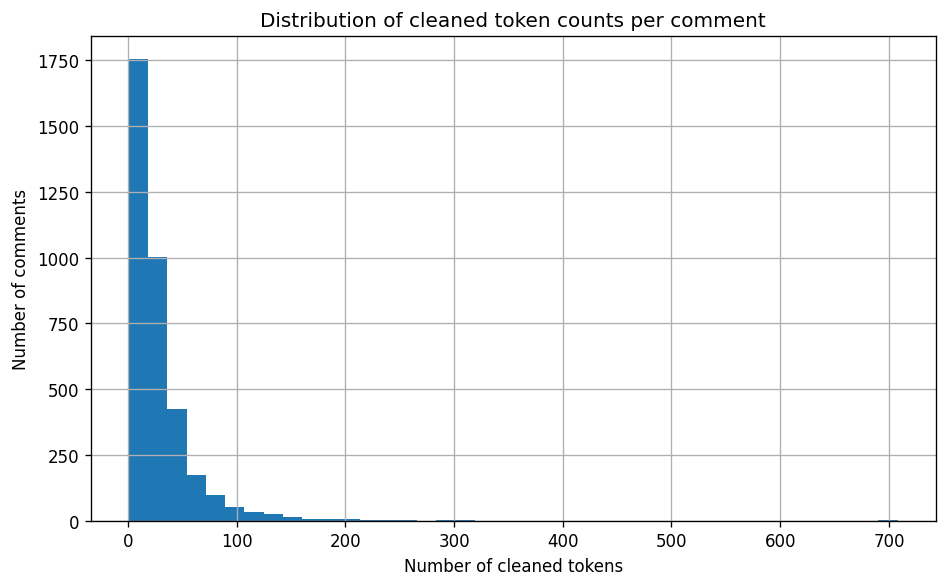

In [22]:
ax = df["n_tokens_clean"].hist(bins=40)

ax.set_xlabel("Number of cleaned tokens")
ax.set_ylabel("Number of comments")
ax.set_title("Distribution of cleaned token counts per comment")

plt.tight_layout()
plt.show()

### explanation
The histogram shows how long the comments are after cleaning and stop word removal. Most comments are relatively short, while a smaller number of comments contain many tokens. This is expected in discussion datasets because many users leave short replies, while a few users write detailed explanations.

In [24]:
from collections import Counter
from nltk.util import ngrams

# Combine all cleaned tokens into one long list
all_tokens = [token for tokens in df["tokens_clean"] for token in tokens]

# Count unigrams
unigram_counts = Counter(all_tokens)

top_cnt = (
    pd.DataFrame(unigram_counts.items(), columns=["token", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

# Create and count bigrams
all_bigrams = list(ngrams(all_tokens, 2))

bigram_counts = Counter(all_bigrams)

top_bi = (
    pd.DataFrame(bigram_counts.items(), columns=["bigram", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

# Convert bigram tuples into readable text
top_bi["bigram"] = top_bi["bigram"].apply(lambda x: " ".join(x))

print("Top 20 cleaned unigrams:")
display(top_cnt.head(20))

print("Top 20 cleaned bigrams:")
display(top_bi.head(20))

Top 20 cleaned unigrams:


,token,count
0,reply,3602
1,n't,1434
2,’,942
3,ai,519
4,code,501
5,time,439
6,google,396
7,work,360
8,really,338
9,make,310


Top 20 cleaned bigrams:


,bigram,count
0,ca n't,176
1,reply ’,98
2,claude code,94
3,reply n't,86
4,n't know,69
5,web components,56
6,reply yeah,51
7,wo n't,47
8,magic lantern,45
9,years ago,43


In [25]:
print("Top 20 cleaned unigrams:")
display(top_cnt.head(20))

print("Top 20 cleaned bigrams:")
display(top_bi.head(20))

Top 20 cleaned unigrams:


,token,count
0,reply,3602
1,n't,1434
2,’,942
3,ai,519
4,code,501
5,time,439
6,google,396
7,work,360
8,really,338
9,make,310


Top 20 cleaned bigrams:


,bigram,count
0,ca n't,176
1,reply ’,98
2,claude code,94
3,reply n't,86
4,n't know,69
5,web components,56
6,reply yeah,51
7,wo n't,47
8,magic lantern,45
9,years ago,43


In [26]:
# Most common bi-grams
def bigrams(lst):
    return list(zip(lst, lst[1:])) if len(lst) > 1 else []
all_bi = []
for row in df['tokens_clean']:
    all_bi.extend(bigrams(row))
bi_cnt = Counter(all_bi)
top_bi = pd.DataFrame([(f"{a} {b}", c) for (a,b), c in bi_cnt.most_common(30)], columns=['bigram','count'])
top_bi.head(10)

,bigram,count
0,ca n't,176
1,claude code,94
2,n't know,69
3,web components,56
4,wo n't,47
5,magic lantern,45
6,years ago,43
7,n't really,41
8,n't want,39
9,social credit,36


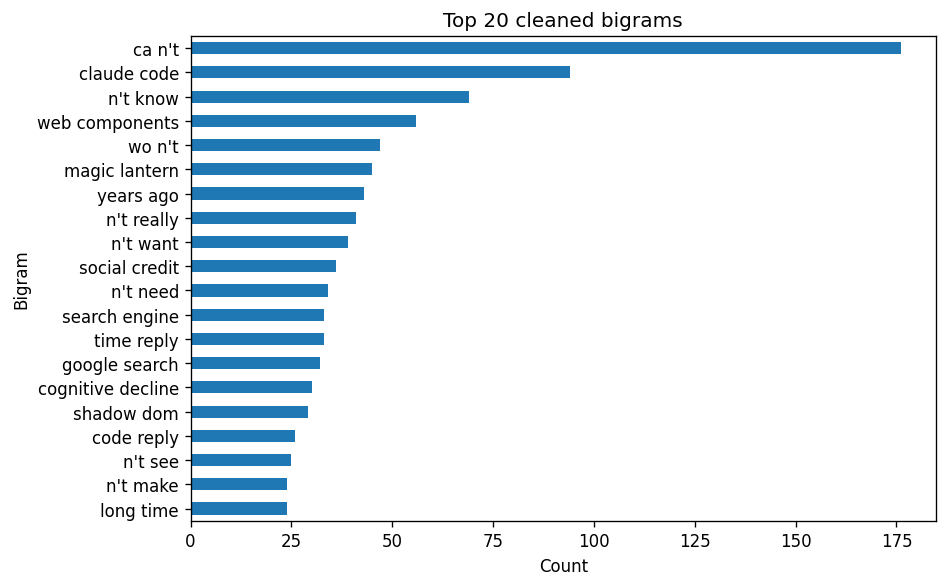

In [28]:
# Visualize with a wordcloud
top_20_bi = top_bi.head(20).sort_values("count")

ax = top_20_bi.plot.barh(x="bigram", y="count", legend=False)
ax.set_xlabel("Count")
ax.set_ylabel("Bigram")
ax.set_title("Top 20 cleaned bigrams")

plt.tight_layout()
plt.show()

## Vectorization

For many applications and analyses, we will need to represent our text data in a numerical fashion, similar to producing a one-hot encoding for a categorical variable. *Term frequency* (TF) and *term frequency-inverse document frequency* (TF-IDF) vectors are two of the more common methods for vectorizing text data. 

A TF vector represents a document (in our case a single comment) as one vector with each position representing a word/token in our dataset. The value of each position for each document is the number of times that word shows up in that document (term frequency).

A TF-IDF vector is set up in the same way, but the value of each position is the number of times that word shows up in that document, divided by the number of documents that have the term.

These vectors are often combined into a single matrix for analysis, called a document-term matrix (since one axis will have the individual documents, and one axis will have the individual words).

**TODO**:
- Use scikit‑learn’s `CountVectorizer` to create a TF document‑term matrix. This function has cleaning steps built into it, so we will apply the function to our `text-norm` column. Choose the appropriate settings to convert the text to lowercase, remove stopwords, ignore words that are in more than 95% of documents, and ignore words that are in fewer than 5 documents.
- Use scikit‑learn’s `TfidfVectorizer` to create a TF-IDF document‑term matrix with the same cleaning settings as the TF matrix.

**Q**: What benefit do we get from using TF-IDF instead of the raw TF matrix?

**A**: TF-IDF is useful because it reduces the influence of words that appear in many documents and gives more weight to terms that are more distinctive to a specific document. A raw term frequency matrix mainly shows how often words occur, so common words can dominate the results. TF-IDF is better when we want to identify words that are important within individual comments, not just frequent across the entire dataset.

**Q**: What differences do you see between the TF and TF-IDF top terms shown below?

**A**: The raw TF top terms are mostly the most frequent words across the entire dataset. These terms show the broad topics of the comments, such as Linux, kernel, security, and code. The TF-IDF terms are similar in some cases, but they give more importance to words that are distinctive within specific comments. As a result, TF-IDF can highlight more specific technical terms and reduce the effect of words that are common across many comments.

In [29]:
cv = CountVectorizer(
    lowercase=True,
    stop_words="english",
    max_df=0.95,
    min_df=5
)

X_tf = cv.fit_transform(df["text_norm"].fillna(""))

vocab = np.array(cv.get_feature_names_out())

print("TF matrix shape:", X_tf.shape)
print("Vocabulary size:", len(vocab))

TF matrix shape: (3607, 3195)
Vocabulary size: 3195


In [30]:
tf_term_counts = np.asarray(X_tf.sum(axis=0)).ravel()

top_tf_terms = (
    pd.DataFrame({
        "term": vocab,
        "count": tf_term_counts
    })
    .sort_values("count", ascending=False)
    .head(20)
)

top_tf_terms

,term,count
1641,like,827
1547,just,825
864,don,636
3035,use,590
127,ai,543
2049,people,521
511,code,507
2912,time,462
2895,think,460
1250,google,405


In [31]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_df=0.95,
    min_df=5
)

X_tfidf = tfidf.fit_transform(df["text_norm"].fillna(""))

tfidf_vocab = np.array(tfidf.get_feature_names_out())

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Vocabulary size:", len(tfidf_vocab))

TF-IDF matrix shape: (3607, 3195)
Vocabulary size: 3195


In [32]:
mean_tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()

top_tfidf_terms = (
    pd.DataFrame({
        "term": tfidf_vocab,
        "mean_tfidf": mean_tfidf_scores
    })
    .sort_values("mean_tfidf", ascending=False)
    .head(20)
)

top_tfidf_terms

,term,mean_tfidf
1641,like,0.021534
1547,just,0.020710
864,don,0.017460
3035,use,0.016671
127,ai,0.015682
2049,people,0.014949
2895,think,0.014605
511,code,0.014518
1250,google,0.014067
2912,time,0.013190


In [33]:
def top_terms(row_vector, vocab, k=10):
    row = row_vector.toarray().ravel()
    idx = row.argsort()[::-1][:k]
    return list(zip(vocab[idx], row[idx]))

for i in np.random.choice(X_tfidf.shape[0], size=3, replace=False):
    print(f"Doc {i} top terms:")
    
    print("Original comment:")
    print(df.loc[i, "comment_text"][:500])
    
    print("\nTF:")
    print(top_terms(X_tf[i], vocab, k=10))
    
    print("\nTF-IDF:")
    print(top_terms(X_tfidf[i], tfidf_vocab, k=10))
    
    print("-" * 80)

Doc 1359 top terms:
Original comment:
Could you please expand on this thought? I'm curious where this abstraction's inflection points are. reply

TF:
[('thought', np.int64(1)), ('points', np.int64(1)), ('curious', np.int64(1)), ('abstraction', np.int64(1)), ('20', np.int64(0)), ('wrote', np.int64(0)), ('000', np.int64(0)), ('zero', np.int64(0)), ('zed', np.int64(0)), ('youtube', np.int64(0))]

TF-IDF:
[('points', np.float64(0.5417231694578728)), ('curious', np.float64(0.5145812293281042)), ('abstraction', np.float64(0.49368577962408955)), ('thought', np.float64(0.44499046854134816)), ('20', np.float64(0.0)), ('wrote', np.float64(0.0)), ('000', np.float64(0.0)), ('zero', np.float64(0.0)), ('zed', np.float64(0.0)), ('youtube', np.float64(0.0))]
--------------------------------------------------------------------------------
Doc 508 top terms:
Original comment:
Blaming the rise of the far-right on Russia is a bit absurd. Immigration isn't popular even if you think it should be. reply

TF:

## Sentiment Analysis
Sentiment analysis is used to produce a score for the "sentiment" of each document in your corpus. It is mosty frequently useful in applications in which you would like to understand the sentiment of a large corpus (e.g. are product reviews generally good or bad) or for segmenting a dataset for further analysis (e.g. within positive reviews, what topics are most common).

Like tokenization and vectorization, sentiment analysis methods range greatly in their complexity. For this analysis we will be applying a static lexicon (VADER) to our text, which maps each word in the dataset to a sentiment score. These scores are then combined to produce a single score for each document--positive values indicate a positive sentiment, and negative values indicate a negative sentiment.

**Q**: What do you notice about our distribution of sentiment scores? How would you expect this to change if we were looking at a dataset of Amazon product reviews?

**A**: The sentiment distribution is centered around neutral, with both positive and negative comments. This makes sense for HackerNews because the comments are often technical, analytical, or argumentative rather than clearly emotional. If this were an Amazon product review dataset, I would expect the sentiment distribution to be more polarized, with many strongly positive reviews and some strongly negative reviews. Product reviews usually contain more opinion words such as "great", "bad", "excellent", or "terrible", while HackerNews comments often discuss technical details in a more neutral tone.

In [34]:
sia = SentimentIntensityAnalyzer()

scores = df["text_norm"].fillna("").apply(sia.polarity_scores)

df["sent_compound"] = scores.apply(lambda d: d["compound"])
df["sent_pos"] = scores.apply(lambda d: d["pos"])
df["sent_neu"] = scores.apply(lambda d: d["neu"])
df["sent_neg"] = scores.apply(lambda d: d["neg"])

df[["text_norm", "sent_compound", "sent_pos", "sent_neu", "sent_neg"]].head()

,text_norm,sent_compound,sent_pos,sent_neu,sent_neg
0,i want to try zed but the helix mode seems qui...,0.8462,0.127,0.843,0.030
1,helix seems to have good lsp support from what...,0.8225,0.202,0.798,0.000
2,if you are already familiar with vim bindings ...,0.2944,0.114,0.886,0.000
3,i love zed and i'm glad you now have native su...,0.9231,0.163,0.808,0.029
4,i was somewhat surprised to find that zed stil...,0.9119,0.183,0.817,0.000


In [35]:
def sentiment_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment_label"] = df["sent_compound"].apply(sentiment_label)

df["sentiment_label"].value_counts()

sentiment_label
positive    2036
negative     891
neutral      680
Name: count, dtype: int64

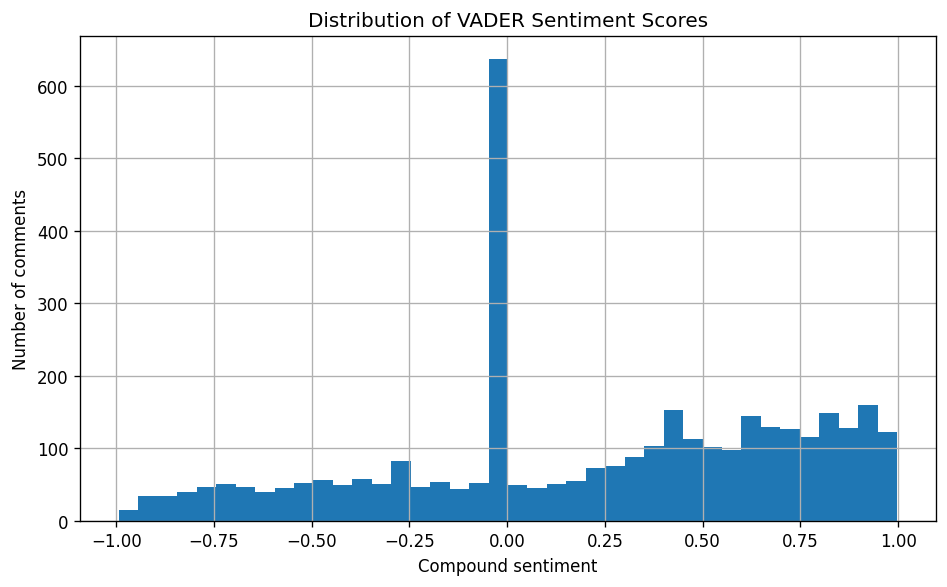

In [36]:
ax = df["sent_compound"].hist(bins=40)

ax.set_xlabel("Compound sentiment")
ax.set_ylabel("Number of comments")
ax.set_title("Distribution of VADER Sentiment Scores")

plt.tight_layout()
plt.show()

In [37]:
sent_by_story = (
    df.dropna(subset=["title"])
    .groupby("title")
    .agg(
        mean_sentiment=("sent_compound", "mean"),
        median_sentiment=("sent_compound", "median"),
        n_comments=("comment_id", "count"),
        mean_score=("score", "mean")
    )
    .sort_values("n_comments", ascending=False)
)

sent_by_story.head(10)

,mean_sentiment,median_sentiment,n_comments,mean_score
title,,,,
Google can keep its Chrome browser but will be barred from exclusive contracts,0.138645,0.07720,575,831.0
"MIT Study Finds AI Use Reprograms the Brain, Leading to Cognitive Decline",0.204133,0.27160,443,455.0
A staff engineer's journey with Claude Code,0.298294,0.36120,348,495.0
Claude Code: Now in Beta in Zed,0.184789,0.08360,184,249.0
Voyager – An interactive video generation model with realtime 3D reconstruction,0.114483,0.00000,181,262.0
"We already live in social credit, we just don't call it that",0.025103,0.00000,160,115.0
"Lit: a library for building fast, lightweight web components",0.305510,0.40685,148,225.0
Magic Lantern Is Back,0.435984,0.62765,144,439.0
This blog is running on a recycled Google Pixel 5 (2024),0.313438,0.36120,141,335.0


## Save Engineered Features
We will save our modified dataset for future use.

In [38]:
features = df[
    [
        "story_id",
        "title",
        "comment_id",
        "user",
        "text_norm",
        "n_tokens_clean",
        "sent_compound",
        "sentiment_label"
    ]
].copy()

OUT_DIR = "data/module2"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, "hn_comment_features.csv")

features.to_csv(OUT_CSV, index=False)

print("Saved engineered features to:", OUT_CSV)

features.head()

Saved engineered features to: data/module2\hn_comment_features.csv


,story_id,title,comment_id,user,text_norm,n_tokens_clean,sent_compound,sentiment_label
0,45116688,Claude Code: Now in Beta in Zed,45118137,unshavedyak,i want to try zed but the helix mode seems qui...,59,0.8462,positive
1,45116688,Claude Code: Now in Beta in Zed,45118867,Karrot_Kream,helix seems to have good lsp support from what...,23,0.8225,positive
2,45116688,Claude Code: Now in Beta in Zed,45118827,yes_but_no,if you are already familiar with vim bindings ...,10,0.2944,positive
3,45116688,Claude Code: Now in Beta in Zed,45118464,ppeetteerr,i love zed and i'm glad you now have native su...,53,0.9231,positive
4,45116688,Claude Code: Now in Beta in Zed,45119080,hajile,i was somewhat surprised to find that zed stil...,45,0.9119,positive


In [ ]:
features = df[['story_id','title','comment_id','user','text_norm','n_tokens_clean','sent_compound']].copy()
OUT_DIR = 'data/module2' ## TODO: Update file path as needed
os.makedirs(OUT_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, 'hn_comment_features.csv')
features.to_csv(OUT_CSV, index=False)
OUT_CSV